# Projeto 4 - Álgebra Linear Numérica

# Questão 1

## Item a)
Para obtermos um vetor na direção de $e_1$ com a mesma norma de $x$, queremos refletir $x$ pelo hiperplano ortogonal a $v = x - \lVert x \rVert e_1$, porque esse hiperplano é a mediatriz de $x$ e $e_1$. 

Nesse caso, a lógica para refletir é a mesma que para projetar! Se nosso projetor  $I - \frac{vv*}{v*v}$ projeta sobre o espaço ortogonal, então subtrair $\frac{vv*}{v*v}x$ de $x$ leva ao espaço ortogonal e, portanto, subtrair $2\frac{vv*}{v*v}x$ "atravessa" esse espaço e chega "do outro lado", na reflexão de $x$ pelo hiperplano. Essa reflexão é, justamente, o vetor $||x||e_1$. Assim, nosso refletor será $Q_v = I - \beta v v^*$.

Determinamos $\beta$ impondo $Q_v x = \lVert x \rVert e_1$:

$$
(I - \beta v v^*) x = \lVert x \rVert e_1
\implies x - \beta v (v^* x) = \lVert x \rVert e_1
\implies \beta (v^* x)\, v = x - \lVert x \rVert e_1 = v
$$

Como $v \neq 0$, concluímos que $\beta v^* x = 1$, e portanto:

$$
\beta = \frac{1}{v^* x} = \frac{1}{(x - \lVert x \rVert e_1)^* x} = \frac{1}{x^*x - \lVert x \rVert e_1^* x} = \frac{1}{\lVert x \rVert^2 - \lVert x \rVert x_1} = \frac{1}{\lVert x \rVert(\lVert x \rVert - x_1)}
$$

# Item b)

No caso em que $x_1$ é positivo, podemos enfrentar problemas ao computar $\frac{1}{\lVert x \rVert(\lVert x \rVert - x_1)}$ porque, se $x$ for muito próximo de $e_1$, $x_1 \approx \lVert x \rVert$ e o termo $\lVert x \rVert - x_1$ pode ficar muito próximo de $0$, o que faria com que $\beta$ "explodisse". Nesse caso, não enfrentamos o mesmo problema com a fórmula $\frac{\lVert x \rVert + x_1}{\lVert x \rVert \cdot \lVert y \rVert}$ porque estamos somando apenas quantidades positivas! 

O exato oposto é válido quando $x$ é negativo: $x$ muito próximo de $e_1$ torna $- x_1 \approx \lVert x \rVert$ e o termo $\lVert x \rVert + x_1$ pode ficar muito próximo de $0$, causando erros para $\frac{\lVert x \rVert + x_1}{\lVert x \rVert \cdot \lVert y \rVert}$, mas não enfrentamos esse problema computando  $\frac{1}{\lVert x \rVert(\lVert x \rVert - x_1)}$

## Item c)

In [29]:
using LinearAlgebra

In [350]:
function reflector(x::AbstractVector{T}) where T<:AbstractFloat
    v = copy(x)
    nrm = norm(x)

    if nrm ≈ 0
        return v, zero(T)
    end

    v[1] -= nrm
    
    if x[1] >= 0
        nrm_resto = norm(@view x[2:end])
        if nrm_resto ≈ 0
            return v, zero(T)
        end
        beta = (nrm + x[1]) / (nrm * nrm_resto ^ 2)
    else
        if nrm_resto ≈ 0
            return v, zero(T)
        end
        beta = one(T) / (nrm * (nrm - x[1]))
    end

    return v, beta
end

@time reflector([0, 0, 0])

  0.000004 seconds (5 allocations: 208 bytes)


([0.0, 0.0, 0.0], 0.0)

## Item d)

O vetor $v$ é definido como:

$$
v = \begin{bmatrix}
x_1 - \lVert x \rVert \\[0.8em]
x_2 \\
x_3 \\
\vdots \\
x_n
\end{bmatrix}
$$

Calculamos o Jacobiano $J = \frac{\partial v}{\partial x}$. Para isso, usamos que:

$$
\frac{\partial \lVert x \rVert}{\partial x_i} = \frac{\partial \sqrt{x_1^2 + \dots + x_n^2}}{\partial x_i} = \frac{x_i}{\lVert x \rVert}, \qquad i = 1, \dots, n
$$

Portanto:

$$
J = \begin{bmatrix}
1 - \dfrac{x_1}{\lVert x \rVert} & -\dfrac{x_2}{\lVert x \rVert} & \cdots & -\dfrac{x_n}{\lVert x \rVert} \\[1.2em]
0 & 1 & \cdots & 0 \\[0.8em]
\vdots & \vdots & \ddots & \vdots \\[0.8em]
0 & 0 & \cdots & 1
\end{bmatrix}
$$

Fatorando, reconhecemos que $J$ pode ser escrito como:

$$
J = I - \frac{1}{\lVert x \rVert}
\begin{bmatrix}
x_1 & x_2 & \cdots & x_n \\[0.8em]
0 & 0 & \cdots & 0 \\[0.8em]
\vdots & \vdots & \ddots & \vdots \\[0.8em]
0 & 0 & \cdots & 0
\end{bmatrix}
= I - \frac{e_1 x^*}{\lVert x \rVert}
$$

Sabe-se que o condicionamento absoluto de $v$ em relação a $x$ se dá por $\hat{\kappa} = \lVert J \rVert$, assim:
$$
\hat{\kappa} = \lVert J \rVert = \lVert I - \frac{e_1 x^*}{\lVert x \rVert} \rVert \leq \lVert I \rVert + \lVert - \frac{e_1 x^*}{\lVert x \rVert} \rVert = 1 + \frac{1}{\lVert x \rVert}\lVert e_1 x^*\rVert \leq 1 + \frac{1}{\lVert x \rVert}\lVert e_1 \rVert \lVert x^* \rVert = 2
$$
Ou seja, o condicionamento absoluto de $v$ em relação a $x$ é $\hat{\kappa} \leq 2$.

## Item e)

In [351]:
x = Float64(10^12)
y = x + 1
x == y

false

In [352]:
for n in [2, 10, 100, 1000, 10_000, 100_000]
    x = rand(n)*2 .- 1
    x64 = Float64.(x)
    x32 = Float32.(x)
    v64, beta64 = reflector(x64)
    v32, beta32 = reflector(x32)
    @show n norm(v32 - v64) norm(beta32 - beta64)
end

n = 2
norm(v32 - v64) = 1.4302065880154376e-8
norm(beta32 - beta64) = 1.302665526736746e-5
n = 10
norm(v32 - v64) = 8.922600969781008e-8
norm(beta32 - beta64) = 2.98445529400837e-9
n = 100
norm(v32 - v64) = 1.6896998272009556e-7
norm(beta32 - beta64) = 1.2385693443084378e-9
n = 1000
norm(v32 - v64) = 6.162051873288945e-7
norm(beta32 - beta64) = 3.7882503774525067e-10
n = 10000
norm(v32 - v64) = 1.816723950016976e-6
norm(beta32 - beta64) = 6.306792382174825e-12
n = 100000
norm(v32 - v64) = 7.128358510278898e-6
norm(beta32 - beta64) = 1.5377527606851883e-12


A princípio, vemos que os valores de $v$ ficam progressivamente mais distantes e que os valores de $\beta$ ficam progressivamente mais próximos à medida em que $n$ aumenta!

In [353]:
norms64 = []
norms32 = []

for n in [2, 10, 100, 1000, 10_000, 100_000]
    x = rand(n)*2 .- 1
    x64 = Float64.(x)
    x32 = Float32.(x)
    target64 = zeros(n)
    target64[1] = norm(x64)
    target32 = zeros(n)
    target32[1] = norm(x32)
    v64, beta64 = reflector(x64)
    v32, beta32 = reflector(x32)
    @views push!(norms64, norm(x64 - beta64*v64*(v64'*x64)- target64))
    @views push!(norms32, norm(x32 - beta32*v32*(v32'*x32)- target32))
end

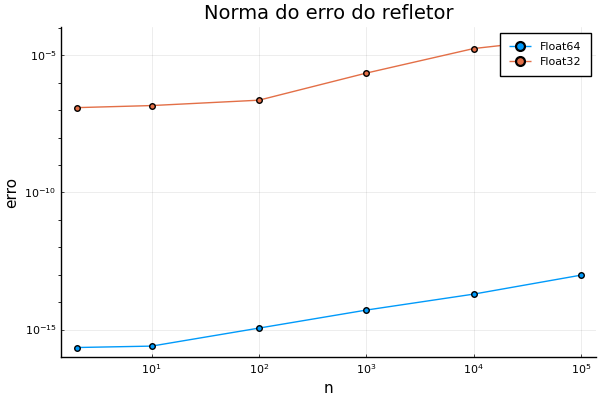

In [354]:
ns = [2, 10, 100, 1000, 10_000, 100_000]
safe64 = [max(x, eps(Float64)) for x in Float64.(norms64)]
safe32 = [max(x, eps(Float32)) for x in Float64.(norms32)]

plot(ns, safe64, label="Float64", marker=:circle,
     xscale=:log10, yscale=:log10,
     xlabel="n", ylabel="erro", title="Norma do erro do refletor", xticks = [10, 100, 1000, 10_000, 100_000])
plot!(ns, safe32, label="Float32", marker=:circle)

In [355]:
@show eps(Float32) eps(Float64)

eps(Float32) = 1.1920929f-7
eps(Float64) = 2.220446049250313e-16


2.220446049250313e-16

Vemos, a partir do gráfico acima, que tanto operando com `Float32` quanto operando com `Float64` a função apresenta erros consideravelmente baixos! Inclusive, para $n$ "pequeno", esse erro é muito próxiimo do epsilon da máquina, de onde vemos que o erro é dominado pela precisão do computador. 

Além disso, a função se comporta surpreendentemente para valores muito grandes de n: o erro cresce lentamente, bem menos que $O(n)$. E, conforme $n$ cresce,  diferença entre os erros para `Float32` e `Float64` se mantém em torno de 8 a 9 ordens de magnitude, o que é compatível com a diferença de precisão aritmética do computador em cada caso. 

Assim, vemos que `reflector` é consideravelmente estável em ambos os casos!

## Item f)

In [356]:
function calc_beta(v::Vector{T}) where T<:AbstractFloat
    return 2/norm(v)^2
end

calc_beta (generic function with 1 method)

In [357]:
norms64 = []
norms32 = []

for n in [2, 10, 100, 1000, 10_000, 100_000]
    x = rand(n)*2 .- 1
    x64 = Float64.(x)
    x32 = Float32.(x)
    target64 = zeros(n)
    target64[1] = norm(x64)
    target32 = zeros(n)
    target32[1] = norm(x32)
    v64, _ = reflector(x64)
    v32, _ = reflector(x32)
    beta64 = calc_beta(v64)
    beta32 = calc_beta(v32)
    @views push!(norms64, norm(x64 - beta64*v64*(v64'*x64)- target64))
    @views push!(norms32, norm(x32 - beta32*v32*(v32'*x32)- target32))
end


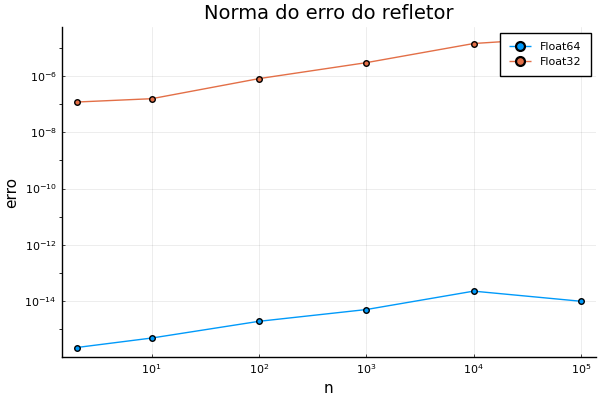

In [358]:
ns = [2, 10, 100, 1000, 10_000, 100_000]
safe64 = [max(x, eps(Float64)) for x in Float64.(norms64)]
safe32 = [max(x, eps(Float32)) for x in Float64.(norms32)]

plot(ns, safe64, label="Float64", marker=:circle,
     xscale=:log10, yscale=:log10,
     xlabel="n", ylabel="erro", title="Norma do erro do refletor", xticks = [10, 100, 1000, 10_000, 100_000])
plot!(ns, safe32, label="Float32", marker=:circle)

A partir do gráfico, vemos que não parece fazer muita diferença calcular $\beta$ diretamente a partir de $v$ ao invés de usar a fórmula aplicada em `reflector`, nem com `Float32` nem com `Float64`. Vejamos, agora, para $x$ cada vez mais perto de $e_1$

In [359]:
using Printf

println("n\t\tk\t\t|beta - beta_v|")
println("-"^50)
for n in [2, 10, 100, 10000]
    for k in 1:3:10
        x = rand(n)*2 .- 1
        x[2:end] .*= 10.0^-k
        v, beta = reflector(x)
        beta_v = calc_beta(v)
        @printf("n=%-6d\tk=%-3d\t\t%.2e\n", n, k, norm(beta - beta_v))
    end
    println()
end

n		k		|beta - beta_v|
--------------------------------------------------
n=2     	k=1  		0.00e+00
n=2     	k=4  		0.00e+00
n=2     	k=7  		0.00e+00
n=2     	k=10 		0.00e+00

n=10    	k=1  		7.11e-15
n=10    	k=4  		0.00e+00
n=10    	k=7  		7.81e-03
n=10    	k=10 		0.00e+00

n=100   	k=1  		0.00e+00
n=100   	k=4  		0.00e+00
n=100   	k=7  		0.00e+00
n=100   	k=10 		0.00e+00

n=10000 	k=1  		3.47e-18
n=10000 	k=4  		0.00e+00
n=10000 	k=7  		7.63e-06
n=10000 	k=10 		0.00e+00



## Item g)

In [360]:
for n in [2, 10, 100, 1000]
    @show n
    for k in 1:3:16
        x = rand(n)*2 .- 1
        x[2:end] .*= 10.0^-k
        v, beta = reflector(x)
        e_1 = zeros(n)
        e_1[1]=1
        J = I -( e_1 * x')/norm(x)
        @show k norm(J)
    end
end

n = 2
k = 1
norm(J) = 2.179057016117353
k = 4
norm(J) = 2.23606797475147
k = 7
norm(J) = 2.236067977499789
k = 10
norm(J) = 1.0
k = 13
norm(J) = 2.23606797749979
k = 16
norm(J) = 1.0
n = 10
k = 1
norm(J) = 3.0364862969645148
k = 4
norm(J) = 3.6055512494317856
k = 7
norm(J) = 3.6055512754639767
k = 10
norm(J) = 3.0
k = 13
norm(J) = 3.605551275463989
k = 16
norm(J) = 3.605551275463989
n = 100
k = 1
norm(J) = 10.069350369769868
k = 4
norm(J) = 9.949891869552474
k = 7
norm(J) = 10.148891565092057
k = 10
norm(J) = 10.14889156509222
k = 13
norm(J) = 9.9498743710662
k = 16
norm(J) = 10.14889156509222
n = 1000
k = 1
norm(J) = 31.652370555796427
k = 4
norm(J) = 31.606967335706237
k = 7
norm(J) = 31.670175244225995
k = 10
norm(J) = 31.606961258558215
k = 13
norm(J) = 31.606961258558215
k = 16
norm(J) = 31.606961258558215


# Questão 2

## Item a)

In [382]:
struct Refletores{T<:Number}
    v::Vector
    beta::T
    dim::Int

    function Refletores(v::Vector, beta::T) where {T<:Number}
        dim = length(v)
        new{T}(v, beta, dim)
    end
    
end

x = [1.0, 2.0, 3.0]
v, beta = reflector(x)
r = Refletores(v, beta)

Refletores{Float64}([-2.7416573867739413, 2.0, 3.0], 0.09748163399326343, 3)

In [383]:
function apply_reflector!(ref::Refletores, b::Vector{<:AbstractFloat})
    @views b[1:ref.dim] .-= ref.beta .* ref.v .*(ref.v ⋅ b[1:ref.dim])
    return b
end

@show apply_reflector!(r, x)

apply_reflector!(r, x) = [3.7416573867739418, -4.440892098500626e-16, -4.440892098500626e-16]


3-element Vector{Float64}:
  3.7416573867739418
 -4.440892098500626e-16
 -4.440892098500626e-16

## Item b)

Para testar nossa função, vamos comparar os resultados de `apply_reflector` com o alvo $\lVert x \rVert e_1$

In [384]:
for i in 2:100:1000
    b = rand(i)
    target = zeros(i)
    target[1] = norm(b)
    v, beta = reflector(b)
    r = Refletores(v, beta)
    apply_reflector!(r, b)
    println("i = ", i, ", norma = ", norm(target - b))
end

for i in 2:100:1000
    for j in i:10:(i+100)
        b = rand(j)
        target = copy(b)
        target[2:i] .= 0
        target[1] = norm(b[1:i])
        v, beta = reflector(b[1:i])
        r = Refletores(v, beta)
        apply_reflector!(r, b)
        println("i = ", i, ", j = ", j, ", norma = ", norm(target - b))
    end
end


i = 2, norma = 1.5700924586837752e-16
i = 102, norma = 6.05425948901555e-16
i = 202, norma = 2.0824815260100516e-15
i = 302, norma = 1.8246405545267753e-15
i = 402, norma = 4.658971064264221e-15
i = 502, norma = 5.576519901948057e-15
i = 602, norma = 5.046010628796758e-15
i = 702, norma = 9.346171848497012e-15
i = 802, norma = 4.12456033967364e-15
i = 902, norma = 1.4425721508395965e-14
i = 2, j = 2, norma = 0.0
i = 2, j = 12, norma = 1.1102230246251565e-16
i = 2, j = 22, norma = 0.0
i = 2, j = 32, norma = 2.9893669801409083e-16
i = 2, j = 42, norma = 1.1102230246251565e-16
i = 2, j = 52, norma = 1.6653345369377348e-16
i = 2, j = 62, norma = 0.0
i = 2, j = 72, norma = 1.5700924586837752e-16
i = 2, j = 82, norma = 1.1102230246251565e-16
i = 2, j = 92, norma = 6.206335383118183e-17
i = 2, j = 102, norma = 1.942890293094024e-16
i = 102, j = 102, norma = 1.7772239894833365e-16
i = 102, j = 112, norma = 3.973231795618356e-15
i = 102, j = 122, norma = 2.9242827974792617e-16
i = 102, j = 132,

Vemos que, em todos os casos, obtemos um erro de ordem $\leq 10^{14}$. Considerando que a precisão da máquina é $10⁻16$, vemos que a função está correta e gera pouquíssimo erro!

Já para verificar a complexidade computacional, vamos testar para vetores cada vez maiores e observar como o tempo de execução cresce.

In [30]:
using BenchmarkTools, Plots

In [366]:
sizes = 1000:2000:50_000
times = zeros(length(sizes))

for (k, i) in enumerate(sizes)
    b = rand(i)
    v, beta = reflector(b)
    r = Refletores(v, beta)
    
    times[k] = @belapsed apply_reflector!($r, b_copy) setup=(b_copy=copy($b))
end

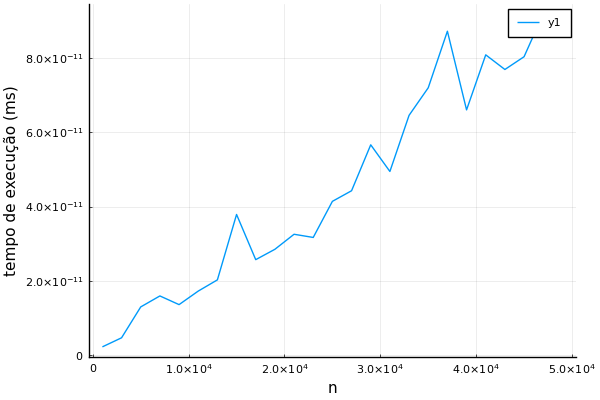

In [367]:
plot(sizes, times ./ 1e6, xlabel="n", ylabel="tempo de execução (ms)")

De fato, o tempo de execução cresce de maneira aproximadamente linear, indicando uma complexidade $O(n)$

## Item c)

In [394]:
function apply_reflector(ref, A)
    A = float(copy(A))
    start = size(A, 1)-ref.dim+1
    A[start:end, :] .-= ref.beta .* ref.v .* (ref.v' * A[start:end, :])
    return A
end

apply_reflector (generic function with 1 method)

## Item d)

In [393]:
function rev_apply_reflector(ref, A)
    A = float(copy(A))
    start = size(A, 2)-ref.dim+1
    A[:, start:end] .-= ref.beta .* (A[:, start:end]*ref.v) .*ref.v'
    return A
end


rev_apply_reflector (generic function with 1 method)

exemplo:

In [397]:
a = [1 2 3; 2 5 6; 3 6 9]
v, beta = reflector(a[2:end,1])
r = Refletores(v, beta)
a = apply_reflector(r, a)
a = rev_apply_reflector(r, a)

3×3 Matrix{Float64}:
 1.0       3.60555   0.0
 3.60555  13.3077    0.461538
 0.0       0.461538  0.692308

## Item e)

In [398]:
function to_hessemberg(A; return_q=false)
    A = float(copy(A))
    reflectors = []
    n = size(A, 1)
    for i in 1:(n-2)
        v, beta = reflector(A[(i+1):end, i])
        r = Refletores(v, beta)
        push!(reflectors, r)
        A = apply_reflector(r, A)
        A = rev_apply_reflector(r, A)
    end
    if return_q
        Q = Matrix(1.0*I, n, n)
        for r in reflectors
            Q = rev_apply_reflector(r, Q)
        end
        return A, reflectors, Q
    end

    return A, reflectors
end

to_hessemberg (generic function with 2 methods)

## Item f)

In [400]:
sizes = [2, 10, 100]
for n in sizes
    @show n
    A = rand(n, n)*10 .- 5
    H, ref, Q = to_hessemberg(A, return_q=true)
    @show norm(A - Q*H*Q')

    S = A'A
    Hs, ref, Qs = to_hessemberg(S, return_q=true)
    @show norm(S - Qs*Hs*Qs')
end

n = 2
norm(A - Q * H * Q') = 0.0
norm(S - Qs * Hs * Qs') = 0.0
n = 10
norm(A - Q * H * Q') = 2.2605886822596132e-14
norm(S - Qs * Hs * Qs') = 1.657319050816788e-13
n = 100
norm(A - Q * H * Q') = 3.4351240316531813e-13
norm(S - Qs * Hs * Qs') = 1.28360995961161e-11


# Questão 3

## Item a)

Os autovalores de $A$ são as raízes do polinômio característico:

$$
\det(A - \lambda I) = \lambda^2 + \omega^2 = 0 \implies \lambda_1 = i\omega, \qquad \lambda_2 = -i\omega
$$

Para os autovetores, resolvemos $(A - \lambda_k I)q_k = 0$ para cada autovalor.

Para $\lambda_1 = i\omega$:

$$
\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} \begin{bmatrix} a \\ c \end{bmatrix} = i\omega \begin{bmatrix} a \\ c \end{bmatrix} 
\implies \begin{cases} c = i \omega a \\ -\omega^2 a = i \omega c \end{cases}
\implies c = i\omega a
$$

Para $\lambda_2 = -i\omega$:

$$
\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} \begin{bmatrix} b \\ d \end{bmatrix} = -i\omega \begin{bmatrix} b \\ d \end{bmatrix}
\implies \begin{cases} d = - i \omega b \\ -\omega^2 b = - i \omega d \end{cases}
\implies d = -i\omega b
$$

Escolhendo $a = b = 1$, os autovetores são:

$$
q_1 = \begin{bmatrix} 1 \\ i\omega \end{bmatrix}, q_2 = \begin{bmatrix} 1 \\ -i\omega \end{bmatrix}
$$

Quando $\omega \to 0$, os autovalores $\lambda_{1,2} = \pm i\omega \to 0$ coincidem, e os autovetores $q_1, q_2 \to \begin{bmatrix} 1 \\ 0 \end{bmatrix}$ também coincidem. Nesse limite, $A$ deixa de ser diagonalizável.

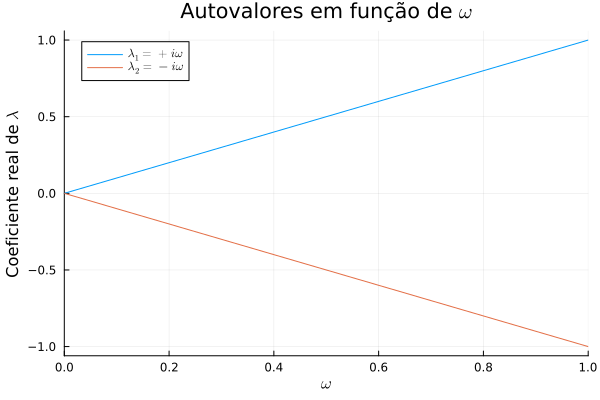

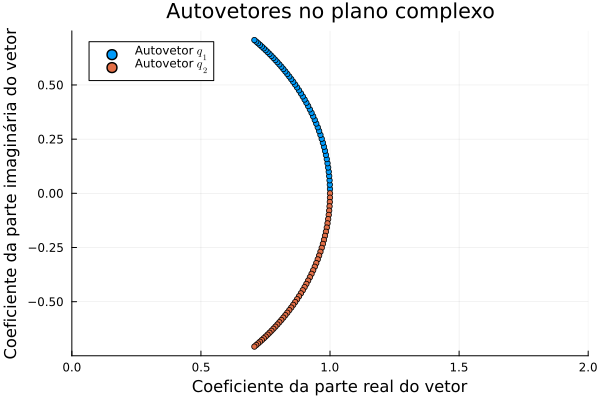

In [46]:
omega_vals = (0:50) / 50
egvln = []
egvlp = []
egvtn = []
egvtp = []

for omega in omega_vals
    A = [  0        1
          -omega^2  0]

    evls = eigvals(A)
    evts = eigvecs(A)

    push!(egvln, evls[1])
    push!(egvlp, evls[2])
    push!(egvtn, evts[:, 1])
    push!(egvtp, evts[:, 2])
end

xs_p = [v[1] for v in egvtp]
ys_p = [v[2] for v in egvtp]
xs_n = [v[1] for v in egvtn]
ys_n = [v[2] for v in egvtn]

p1 = plot(omega_vals, imag.(egvlp),
    label = "\$\\lambda_1 = +i\\omega\$",
    xlabel = "\$\\omega\$",
    ylabel = "Coeficiente real de \$\\lambda\$",
    title = "Autovalores em função de \$\\omega\$",
    legend = :topleft)
plot!(p1, omega_vals, imag.(egvln),
    label = "\$\\lambda_2 = -i\\omega\$")
xlims!(p1, (0, 1))

p2 = scatter(real.(xs_p), imag.(ys_p),
    label = "Autovetor \$q_1\$",
    xlabel = "Coeficiente da parte real do vetor",
    ylabel = "Coeficiente da parte imaginária do vetor",
    title = "Autovetores no plano complexo",
    legend = :topleft,
    markersize = 3)
scatter!(p2, real.(xs_n), imag.(ys_n),
    label = "Autovetor \$q_2\$",
    markersize = 3)
xlims!(p2, (0, 2))

display(p1)
display(p2)

## Item b)

$$
A^*A =
\begin{bmatrix} 0 & -\omega^2 \\ 1 & 0 \end{bmatrix} \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} =
\begin{bmatrix} \omega^4 & 0 \\ 0 & 1 \end{bmatrix}
$$

Os valores singulares de $A$ são as raízes quadradas dos autovalores de $A^*A$. Calculamos o polinômio característico:

$$
\det(A^*A - \lambda I) = (\omega^4 - \lambda)(1 - \lambda) = 0
\implies \lambda_1 = 1, \quad \lambda_2 = \omega^4
$$

Portanto, os valores singulares são:

$$
\sigma_1 = \sqrt{\lambda_1} = 1, \qquad \sigma_2 = \sqrt{\lambda_2} = \omega^2
$$

Para os autovetores, resolvemos $(A^*A - \lambda_k I)v_k = 0$ para cada autovalor.

Para $\lambda_1 = 1$:

$$
\begin{bmatrix} \omega^4 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} a \\ c \end{bmatrix} = \begin{bmatrix} a \\ c \end{bmatrix}
\implies \begin{cases} \omega^4 a = a \\ c = c \end{cases}
\implies a = 0, c \in \mathbb{R}
$$

Para $\lambda_2 = \omega^4$:

$$
\begin{bmatrix} \omega^4 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} b \\ d \end{bmatrix} = \omega^4 \begin{bmatrix} b \\ d \end{bmatrix}
\implies \begin{cases} b = b \\ \omega^4 d = d \end{cases}
\implies b \in \mathbb{R}, d = 0
$$

Escolhendo $c = d = 1$, os vetores que compõem a matriz $V$ são:

$$
v_1 = \begin{bmatrix} 0 \\ 1 \end{bmatrix}, \qquad v_2 = \begin{bmatrix} 1 \\ 0 \end{bmatrix}
$$

Como $\dfrac{Av_k}{\sigma_k} = u_k$:

Para $\sigma_1 = 1$, $v_1 = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$:

$$u_1 = \frac{Av_1}{\sigma_1} = \frac{1}{1}\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}\begin{bmatrix} 0 \\ 1 \end{bmatrix} = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$$

Para $\sigma_2 = \omega^2$, $v_2 = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$:

$$u_2 = \frac{Av_2}{\sigma_2} = \frac{1}{\omega^2}\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}\begin{bmatrix} 1 \\ 0 \end{bmatrix} = \frac{1}{\omega^2}\begin{bmatrix} 0 \\ -\omega^2 \end{bmatrix} = \begin{bmatrix} 0 \\ -1 \end{bmatrix}$$

Portanto, a decomposição SVD de $A$ é $A = U\Sigma V^*$, com:

$$
U = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}, \qquad
\Sigma = \begin{bmatrix} 1 & 0 \\ 0 & \omega^2 \end{bmatrix}, \qquad
V = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}
$$

Como $\omega \in [0, 1]$, temos $\omega^2 \leq 1$, ou seja, $\sigma_2 \leq \sigma_1$. O número de condicionamento de $A$ é dado por:

$$
\kappa(A) = \frac{\sigma_{\max}}{\sigma_{\min}} = \frac{\sigma_1}{\sigma_2} = \frac{1}{\omega^2}
$$

Como visto na questão anterior, a matriz de autovetores de $A$ é $Q = \begin{bmatrix} 1 & 1 \\ i\omega & -i\omega \end{bmatrix}$.
$$
Q^*Q =
\begin{bmatrix} 1 & -i\omega \\ 1 & i\omega \end{bmatrix}
\begin{bmatrix} 1 & 1 \\ i\omega & -i\omega \end{bmatrix} =
\begin{bmatrix} 1 + \omega^2 & 1 - \omega^2 \\ 1 - \omega^2 & 1 + \omega^2 \end{bmatrix}
$$

Os valores singulares de $Q$ são as raízes quadradas dos autovalores de $Q^*Q$. Calculamos o polinômio característico:

$$
\det(Q^*Q - \lambda I) = (1+\omega^2-\lambda)^2 - (1-\omega^2)^2 = 0
$$

Fatorando como diferença de quadrados:

$$
\bigl[(1+\omega^2-\lambda) - (1-\omega^2)\bigr]\bigl[(1+\omega^2-\lambda) + (1-\omega^2)\bigr] = 0
$$
$$
(2\omega^2 - \lambda)(2 - \lambda) = 0
\implies \lambda_1 = 2, \quad \lambda_2 = 2\omega^2
$$

Portanto, os valores singulares são:

$$
\sigma_1 = \sqrt{2}, \qquad \sigma_2 = \sqrt{2}\,\omega
$$

Como $\omega \in [0, 1]$, temos $\sigma_2 \leq \sigma_1$. O número de condicionamento de $Q$ é dado por:

$$
\kappa(Q) = \frac{\sigma_{\max}}{\sigma_{\min}} = \frac{\sigma_1}{\sigma_2} = \frac{\sqrt{2}}{\sqrt{2}\,\omega} = \frac{1}{\omega}
$$

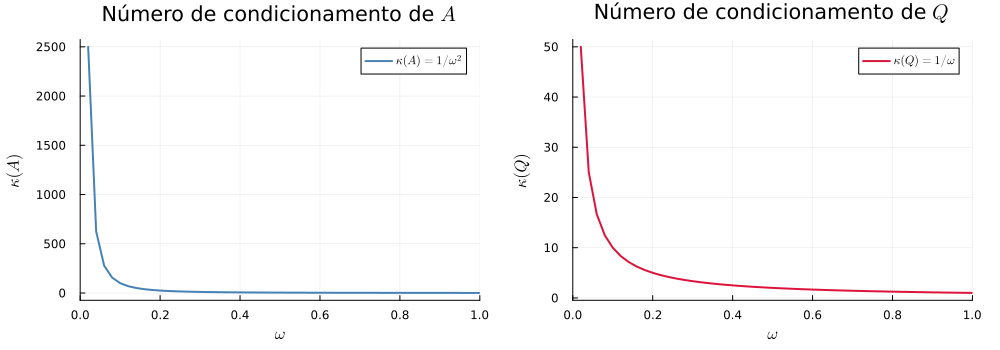

In [ ]:
omega_vals = (1:50) / 50
cond_A = Float64[]
cond_Q = Float64[]

for omega in omega_vals
    A = [0      1
         -omega^2  0]

    _, S, _ = svd(A)
    push!(cond_A, S[1] / S[end])

    Q = eigvecs(A)
    _, S, _ = svd(Q)
    push!(cond_Q, S[1] / S[end])
end

p1 = plot(omega_vals, cond_A,
    title  = "Número de condicionamento de \$A\$",
    xlabel = "\$\\omega\$",
    ylabel = "\$\\kappa(A)\$",
    label  = "\$\\kappa(A) = 1/\\omega^2\$",
    lw = 2,
    color  = :steelblue)
xlims!(p1, (0, 1))

p2 = plot(omega_vals, cond_Q,
    title  = "Número de condicionamento de \$Q\$",
    xlabel = "\$\\omega\$",
    ylabel = "\$\\kappa(Q)\$",
    label  = "\$\\kappa(Q) = 1/\\omega\$",
    lw = 2,
    color  = :crimson)
xlims!(p2, (0, 1))

plot(p1, p2, layout = (1, 2), size = (1000, 350), margin = 5Plots.mm)

## Item c)

Calculamos $A^2$:

$$
A^2 = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} =
\begin{bmatrix} -\omega^2 & 0 \\ 0 & -\omega^2 \end{bmatrix} = -\omega^2 I
$$

Portanto $A^{2k} = (-\omega^2)^k I$ e $A^{2k+1} = (-\omega^2)^k A$. Separando a série de Taylor de $e^{tA}$ em termos pares e ímpares:

$$
e^{tA} = \sum_{k=0}^{\infty} \frac{t^{2k} A^{2k}}{(2k)!} + \sum_{k=0}^{\infty} \frac{t^{2k+1} A^{2k+1}}{(2k+1)!}
= \sum_{k=0}^{\infty} \frac{(-1)^k \omega^{2k} t^{2k}}{(2k)!} I + \sum_{k=0}^{\infty} \frac{(-1)^k \omega^{2k} t^{2k+1}}{(2k+1)!} A
$$

$$
= I \sum_{k=0}^{\infty} \frac{(-1)^k (\omega t)^{2k}}{(2k)!} + \frac{A}{\omega} \sum_{k=0}^{\infty} \frac{(-1)^k (\omega t)^{2k+1}}{(2k+1)!}
$$

Reconhecendo as séries de cosseno e seno:

$$
e^{tA} = \cos(\omega t)\, I + \frac{\sin(\omega t)}{\omega} A
$$

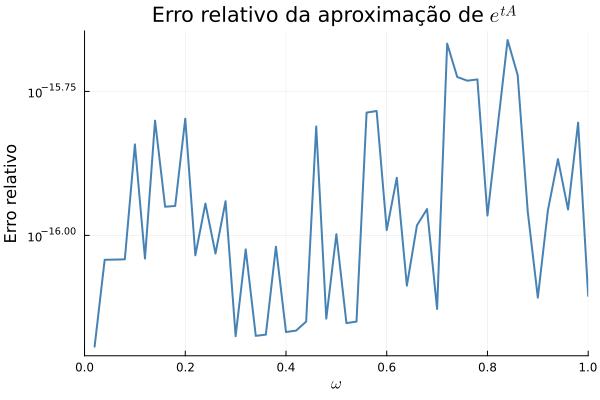

In [65]:
omega_vals = (0:50) / 50
error_norm = Float64[]
t = 1

for omega in omega_vals
    A = [0      1
         -omega^2  0]

    push!(error_norm, norm(exp(t * A) - (cos(omega * t) * I + (sin(omega * t) / omega) * A)) / norm(exp(t * A)))
end

plot(omega_vals, error_norm,
    title = "Erro relativo da aproximação de \$e^{tA}\$",
    xlabel = "\$\\omega\$",
    ylabel = "Erro relativo",
    legend = false,
    lw = 2,
    yscale = :log10,
    color = :steelblue)
xlims!(0, 1)
